# GeoBench Burn Scars

In [1]:
import os
from pathlib import Path

import torch

from geobench_v2.datamodules import GeoBenchBurnScarsDataModule
from geobench_v2.datasets import GeoBenchBurnScars
from geobench_v2.datasets.normalization import SatMAENormalizer, ZScoreNormalizer
from geobench_v2.datasets.visualization_util import (
    compare_normalization_methods,
    compute_batch_histograms,
    plot_batch_histograms,
    plot_channel_histograms,
    visualize_segmentation_target_statistics,
)

%load_ext autoreload
%autoreload 2

/opt/app-root/src/fm-geospatial/pf/envs/geo-env/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/app-root/src/fm-geospatial/pf/envs/geo-env/lib64/python3.11/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [5]:
PROJECT_ROOT = Path("../../")

STATS_SATMAE_PATH = os.path.join(
    PROJECT_ROOT,
    "geobench_v2",
    "datamodules",
    "dataset_stats_satmae",
    "burn_scars",
    "burn_scars.json",
)
STATS_CLIP_RESCALE_PATH = os.path.join(
    PROJECT_ROOT,
    "geobench_v2",
    "datamodules",
    "dataset_stats_clip_rescale",
    "burn_scars",
    "burn_scars.json",
)

In [8]:
band_order = GeoBenchBurnScars.band_default_order


datamodule = GeoBenchBurnScarsDataModule(
    img_size=256,
    batch_size=16,
    num_workers=4,
    root=PROJECT_ROOT,
    band_order=band_order,
    data_normalizer=torch.nn.Identity(),
    download=True
    
)
datamodule.setup("fit")

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5.49G/5.49G [03:07<00:00, 29.3MB/s]


Using provided pre-initialized normalizer instance: Identity
Using provided pre-initialized normalizer instance: Identity


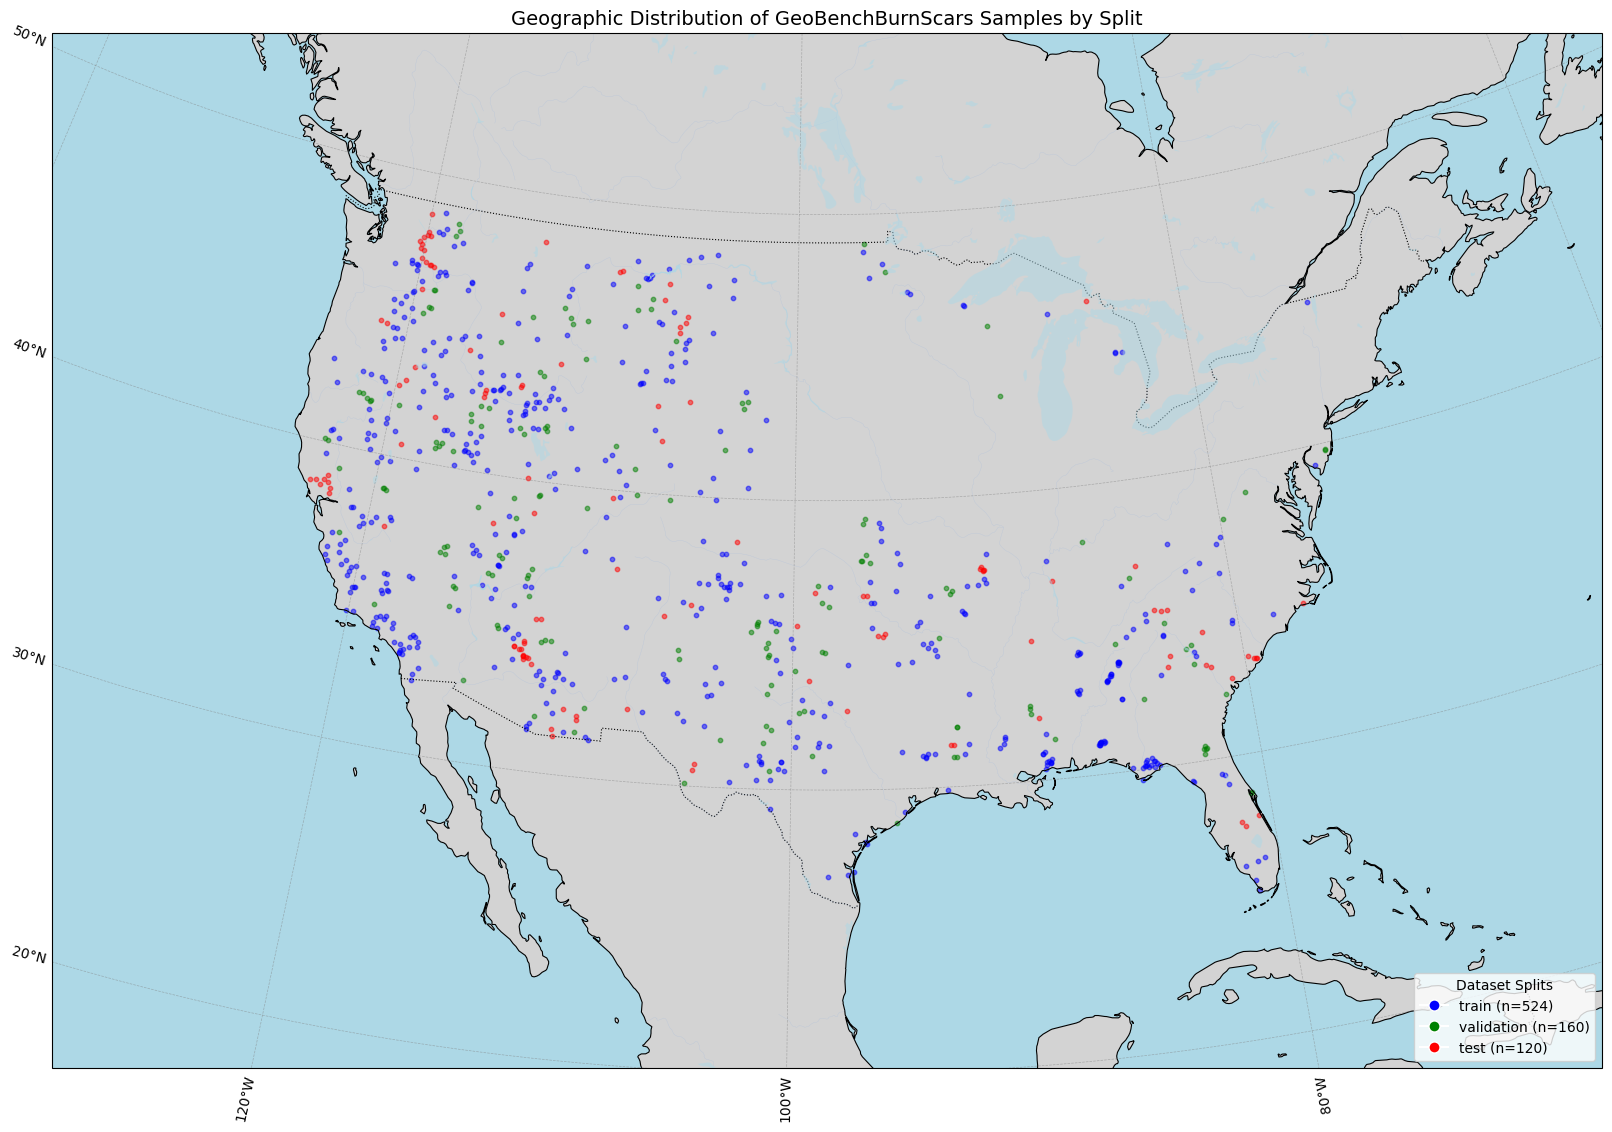

In [9]:
sample_dist_fig = datamodule.visualize_geospatial_distribution()

## Dataset Statistics

Computed over the training dataset.

### Image Dataset Statistics

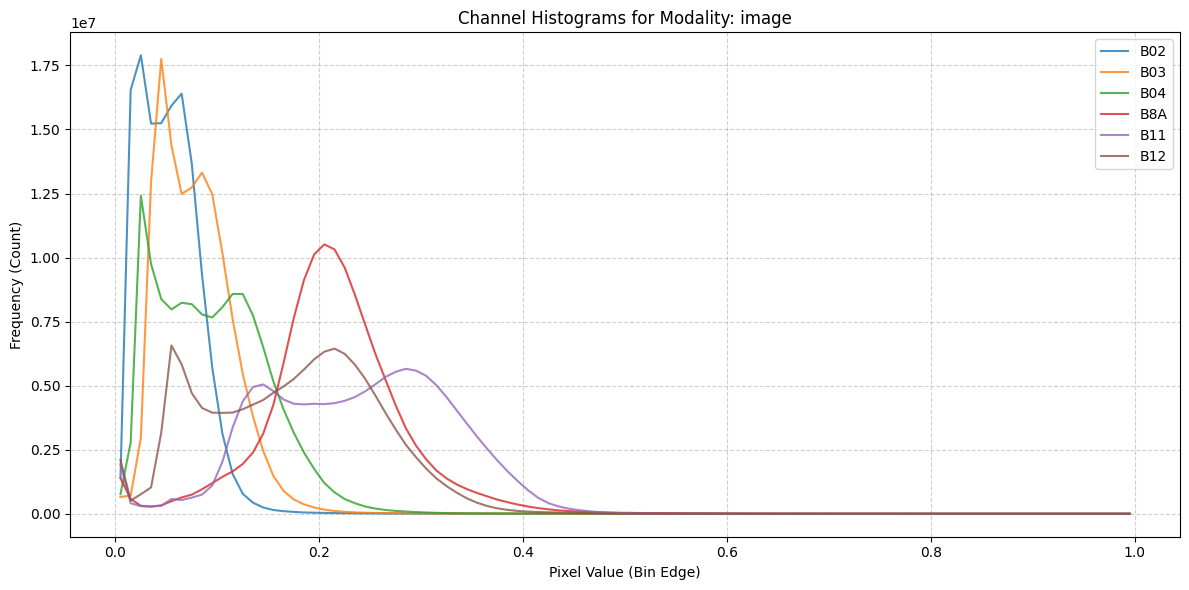

In [11]:
fig = plot_channel_histograms(STATS_SATMAE_PATH)

### Target Statistics

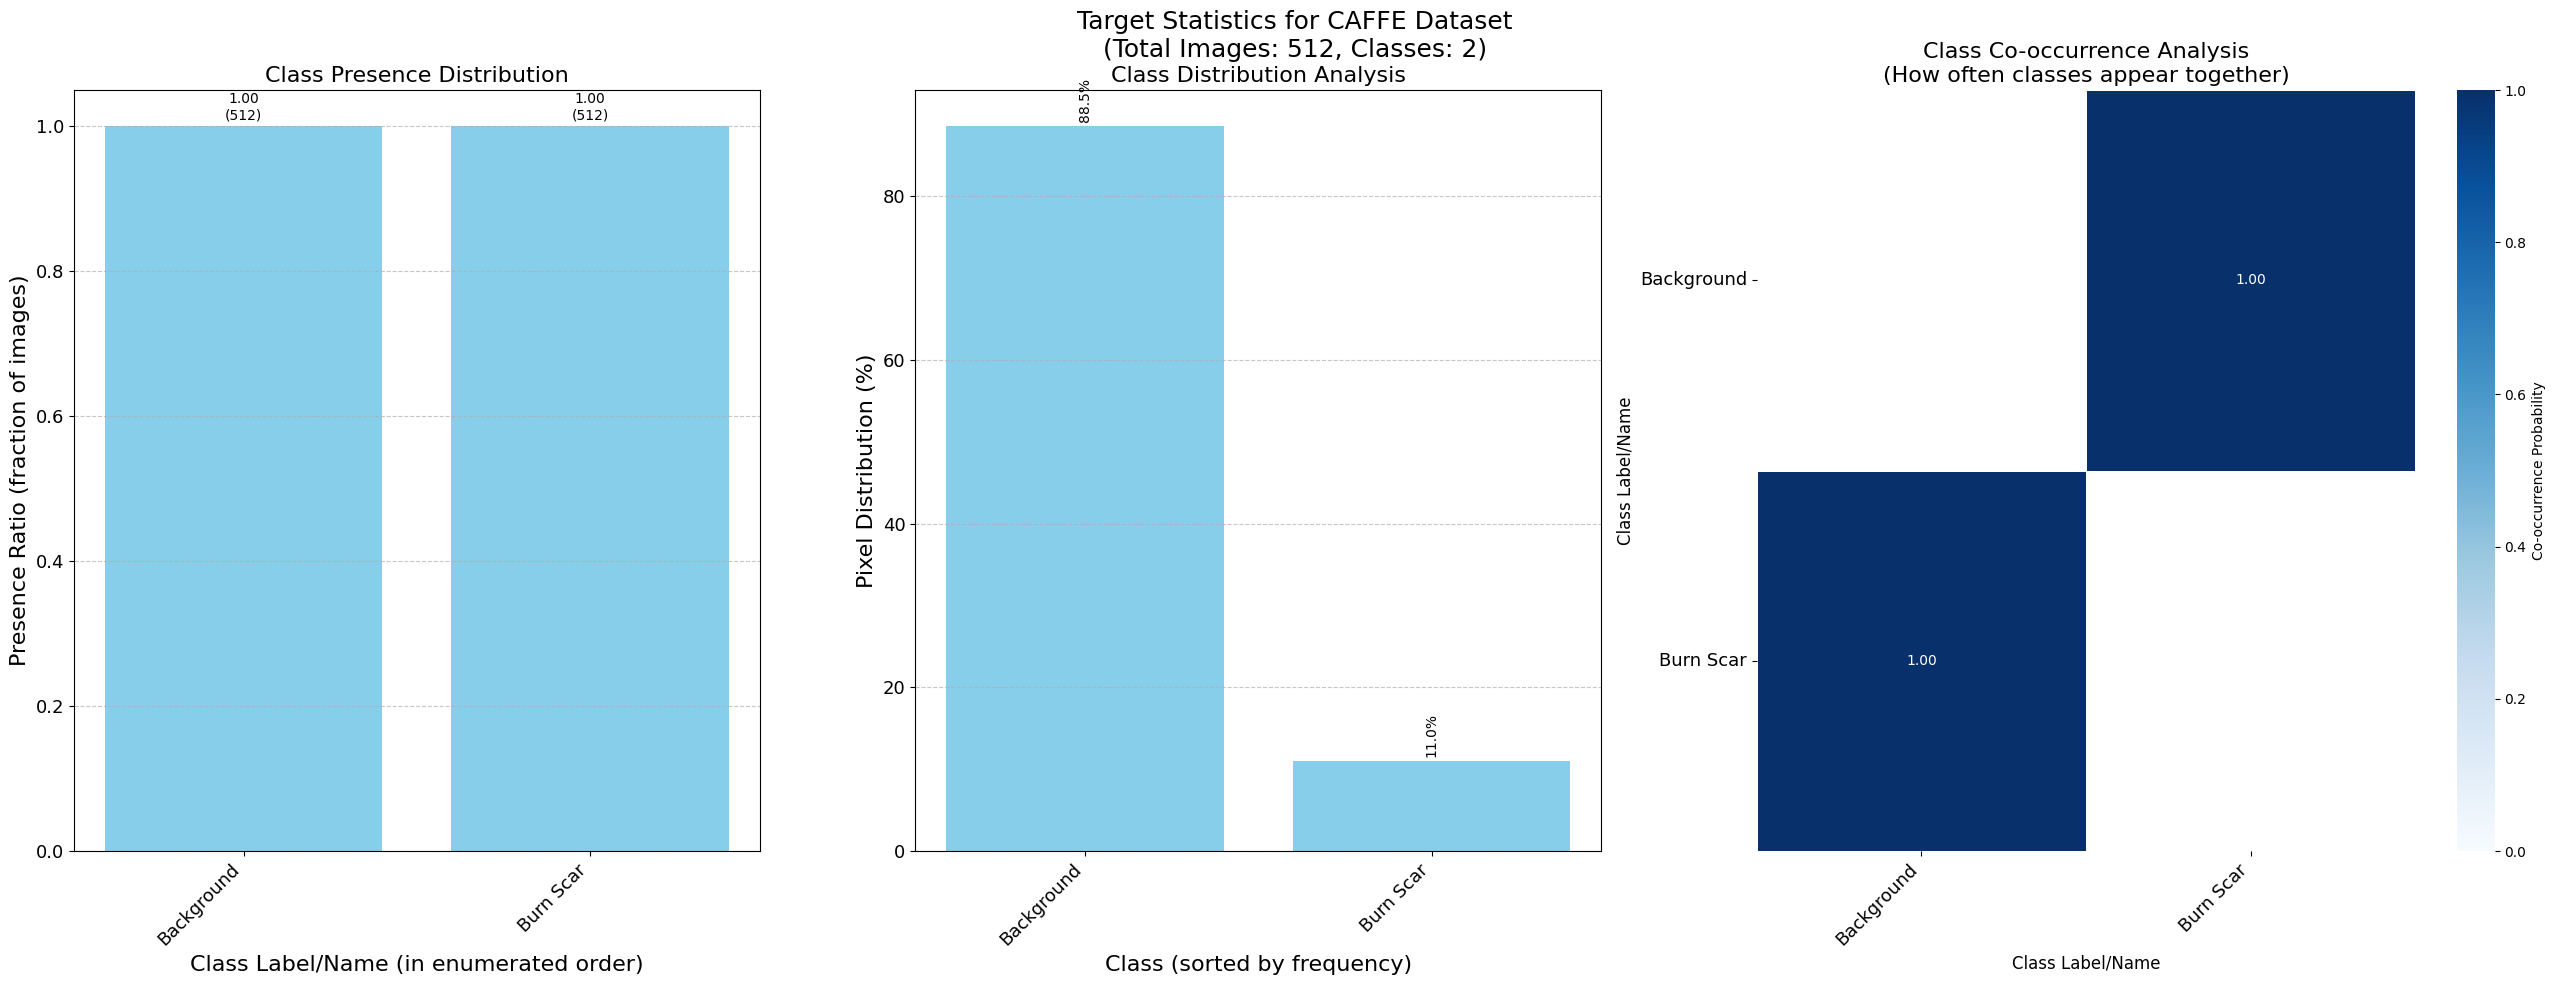

In [12]:
fig = visualize_segmentation_target_statistics(STATS_SATMAE_PATH, "CaFFe")

### Raw Batch Statistics

[<Figure size 1200x500 with 1 Axes>]

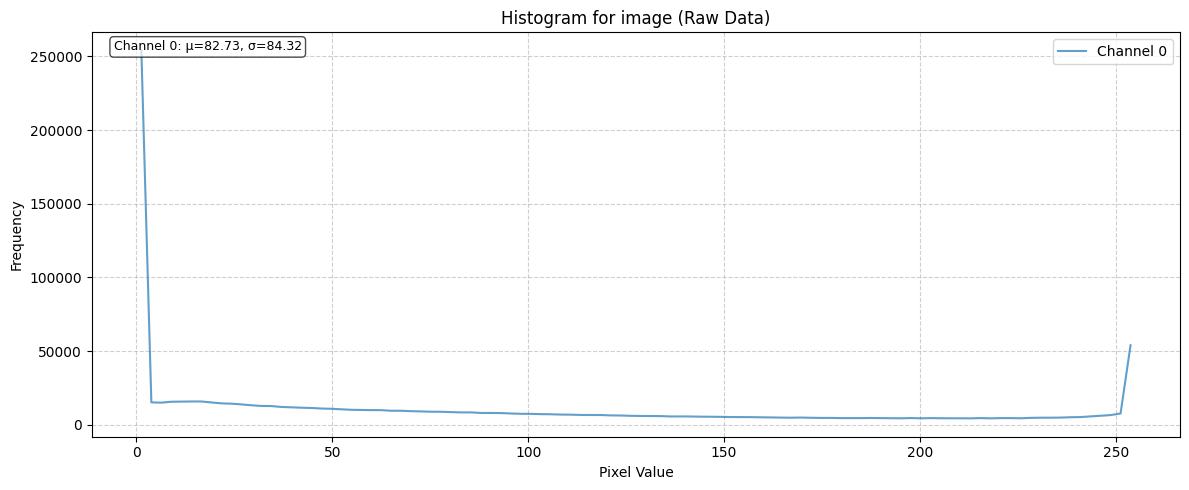

In [7]:
# Get a batch of data from the dataloader
train_dataloader = datamodule.train_dataloader()
raw_batch = next(iter(train_dataloader))

raw_batch_stats = compute_batch_histograms(raw_batch, n_bins=100)


raw_figs = plot_batch_histograms(
    raw_batch_stats, band_order, title_suffix=" (Raw Data)"
)
raw_figs

### Effect of different Normalization Schemes

## Visualize Batch Data

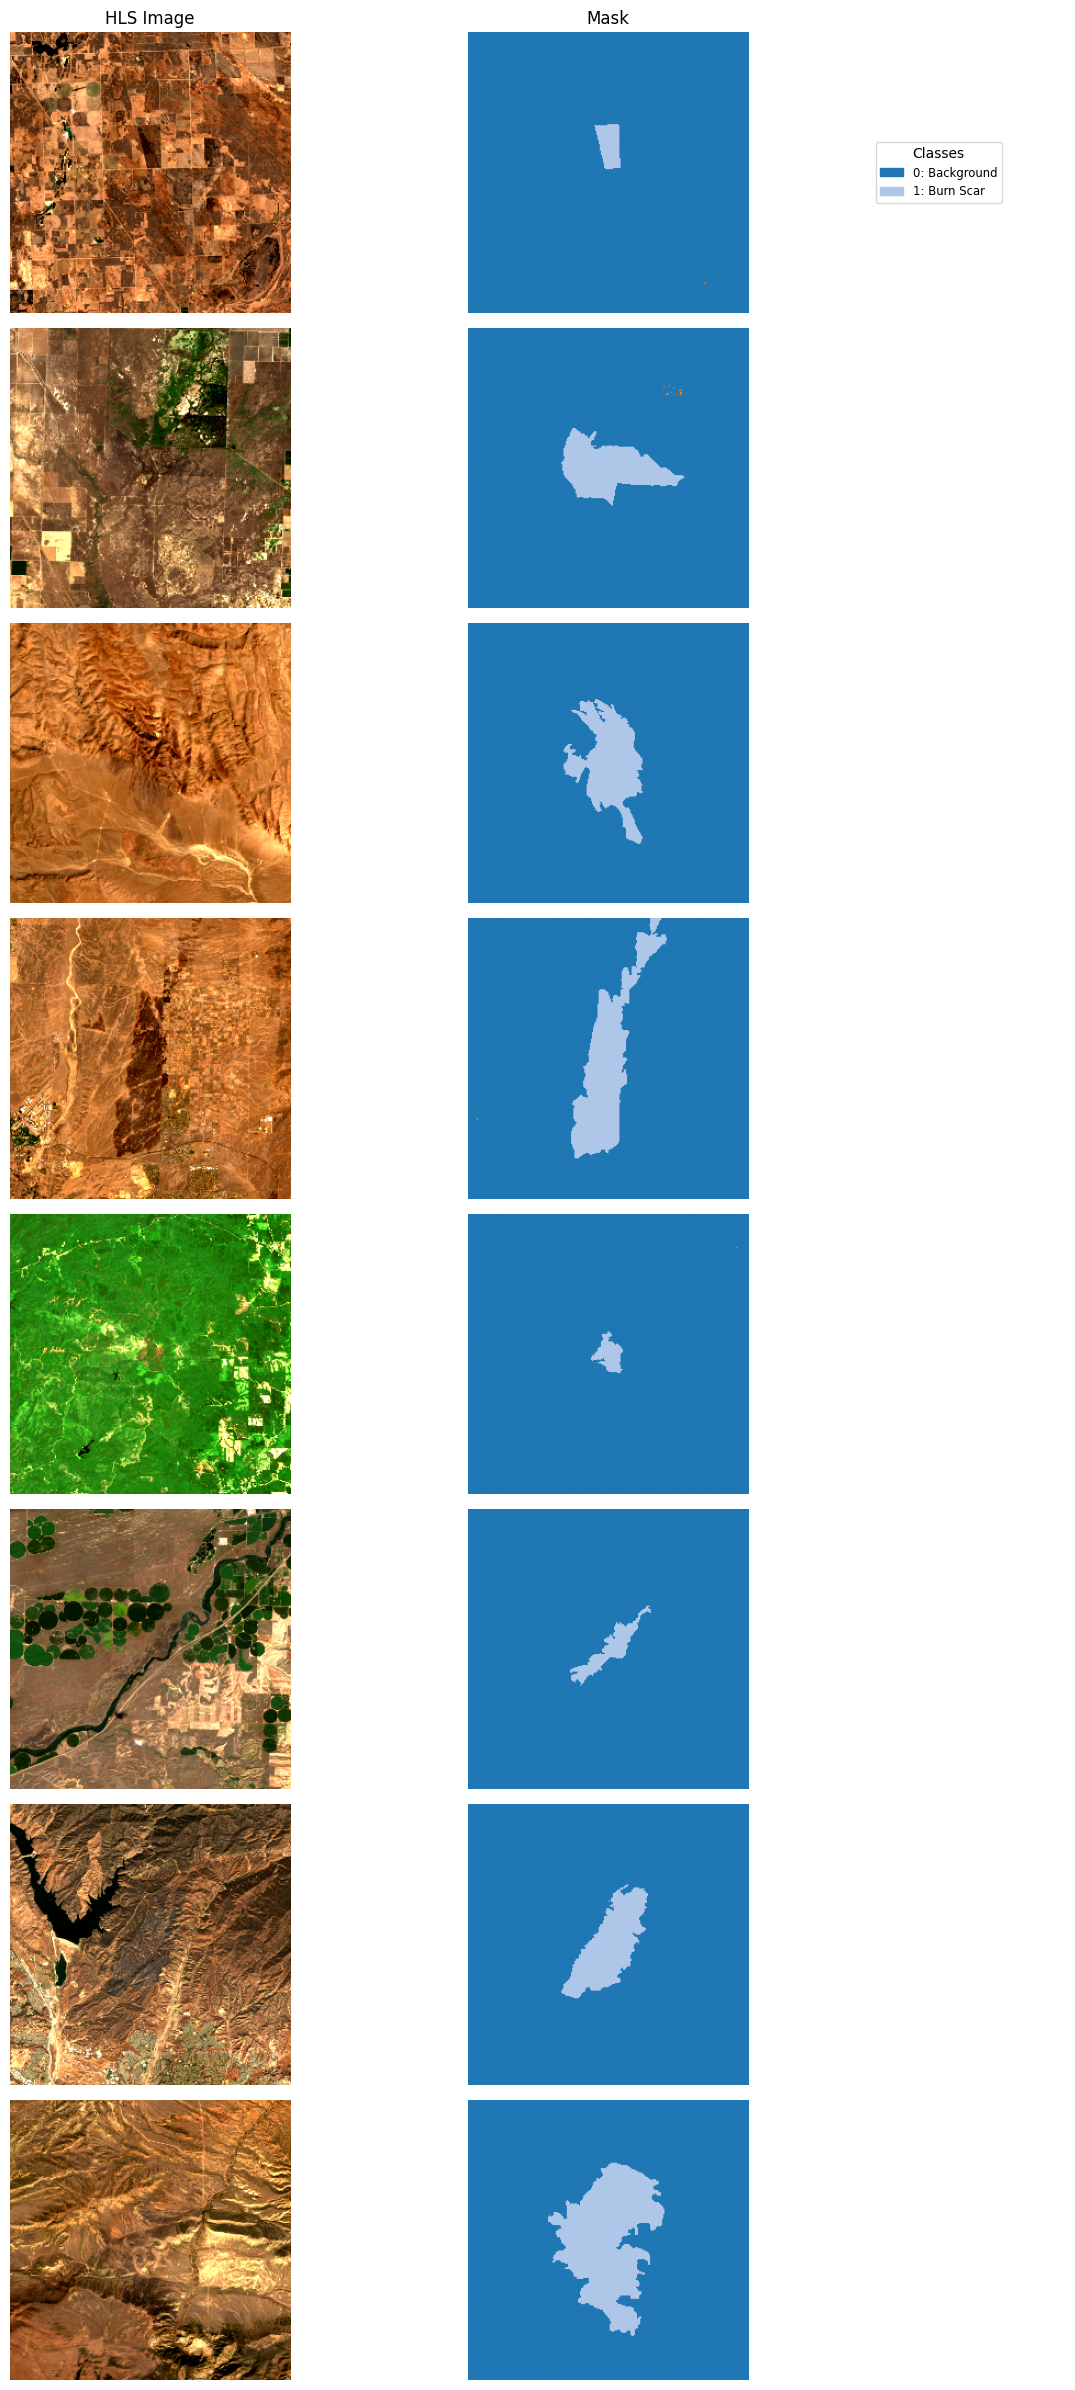

In [15]:
fig, batch = datamodule.visualize_batch()